# Nuclear Waste Canister Temperature Prediction
**CIVIL-226 - Introduction to Machine Learning for Engineers**




**Members:** Nour NAJA |Alessandro CLERICI

## Objectif
Prédire la température autour de conteneurs de déchets nucléaires à des positions de capteurs non observés, en utilisant la puissance de chauffage, le temps, et les coordonnées spatiales des capteurs.

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Chargement des données

In [3]:
sensors = pd.read_parquet('data/sensors.parquet')
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')

# Suppression des capteurs dupliqués (N206 et N213 — coordonnées identiques, erreur de reporting)
n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_before - len(sensors)} (N206, N213)')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Doublons supprimés : 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Exploration des données (EDA)

In [4]:
print('=== SENSORS ===')
display(sensors.head())
print(f'\n{sensors["sensor"].nunique()} capteurs uniques')

print('\n=== TRAIN ===')
display(train.head())
print(f'\nValeurs manquantes :')
print(train.isnull().sum())

=== SENSORS ===


,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0



323 capteurs uniques

=== TRAIN ===


,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427



Valeurs manquantes :
sensor             0
time               0
power              0
temperature    99403
dtype: int64


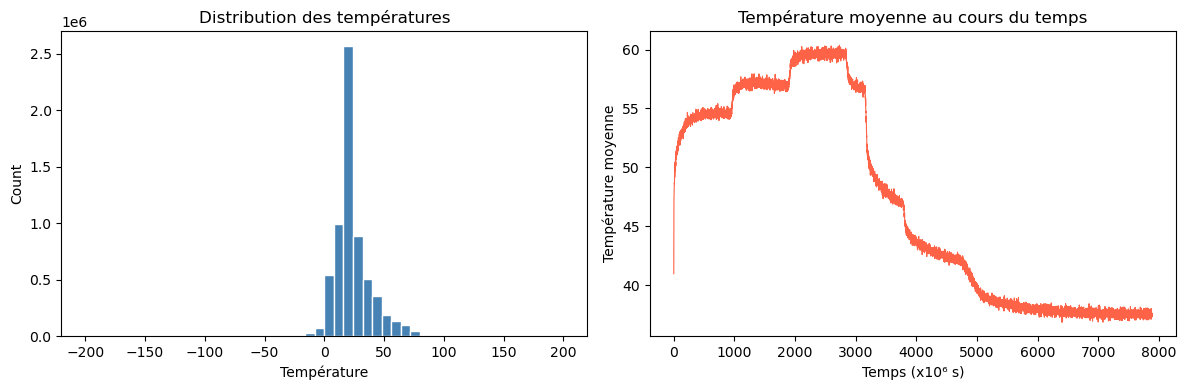

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['temperature'].dropna(), bins=50, color='steelblue',
             edgecolor='white', range=(-200, 200))
axes[0].set_title('Distribution des températures')
axes[0].set_xlabel('Température'); axes[0].set_ylabel('Count')

temp_by_time = train.groupby('time')['temperature'].mean()
axes[1].plot(temp_by_time.index / 1e6, temp_by_time.values, color='tomato', linewidth=0.8)
axes[1].set_title('Température moyenne au cours du temps')
axes[1].set_xlabel('Temps (x10⁶ s)'); axes[1].set_ylabel('Température moyenne')

plt.tight_layout(); plt.show()

In [6]:
import plotly.graph_objects as go
train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())
s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

fig = go.Figure()
fig.add_trace(go.Scatter(x=s_train['coor_x'], y=s_train['coor_y'],
    mode='markers', name='Train sensors',
    marker=dict(size=6, color='steelblue', opacity=0.6)))
fig.add_trace(go.Scatter(x=s_test['coor_x'], y=s_test['coor_y'],
    mode='markers', name='Test sensors',
    marker=dict(size=8, color='tomato', symbol='diamond', opacity=0.9)))
fig.update_layout(title='Positions des capteurs (2D)',
    xaxis_title='X', yaxis_title='Y', width=700, height=500)
fig.show()

print(f'Capteurs train dans buffer (x<=1.4) : {(s_train["coor_x"] <= 1.4).sum()}')
print(f'Capteurs test dans buffer (x<=1.4)  : {(s_test["coor_x"] <= 1.4).sum()}')

Capteurs train dans buffer (x<=1.4) : 56
Capteurs test dans buffer (x<=1.4)  : 18


## 4. Preprocessing

### 4.1 Gestion des valeurs manquantes et aberrants

Le train set contient ~99k valeurs manquantes et ~108k températures aberrantes (hors [-10°C, 200°C]).
On les supprime **avant** le split train/val pour éviter de contaminer l'évaluation.

In [7]:
print(f'Lignes avant nettoyage : {len(train)}')
train_clean = train.dropna(subset=['temperature']).copy()
print(f'Après suppression NaN : {len(train_clean)}')

mask_clean = (train_clean['temperature'] > -10) & (train_clean['temperature'] < 200)
train_clean = train_clean[mask_clean].copy()
print(f'Après filtrage aberrants : {len(train_clean)}')
print(f'Total supprimées : {len(train) - len(train_clean)} ({100*(len(train)-len(train_clean))/len(train):.1f}%)')

Lignes avant nettoyage : 6626928
Après suppression NaN : 6527525
Après filtrage aberrants : 6418812
Total supprimées : 208116 (3.1%)


### 4.2 Feature Engineering

Features motivées par la physique du transfert thermique :
- **dist_canister** : la température décroît avec la distance au canister
- **is_opa** : zone OPA pondérée plus fortement dans le score Kaggle
- **time_log** : capture la dynamique exponentielle du transfert thermique
- **power_x_time, dist_x_time** : interactions physiques entre puissance, distance et temps
- **inv_dist_canister** : gradient radial près du canister
- **coor_x_squared** : non-linéarité spatiale en x
- **time_x_dist** : propagation du front thermique

In [8]:
def add_features(df, sensors_df):
    """
    Joint les coordonnées spatiales et ajoute des features dérivées.

    Features :
    - coor_x, coor_y : position spatiale (coor_z = 0 partout -> ignoré)
    - dist_center : distance à l'origine
    - dist_canister : distance au centre du canister (x=0.7, y=1.2)
    - is_opa : 1 si zone OPA (x > 1.4m), 0 si buffer
    - time_norm : temps normalisé [0, 1]
    - time_log : log(1+t) pour capturer la dynamique exponentielle
    - power_x_time : interaction puissance × temps
    - dist_x_time : interaction distance × temps
    - x_x_time : interaction position x × temps
    - dist_x_log : interaction distance × log(temps)
    - inv_dist_canister : inverse de la distance (gradient radial)
    - coor_x_squared : non-linéarité spatiale en x
    - time_x_dist : propagation du front thermique
    """
    merged = df.merge(sensors_df, on='sensor', how='left')

    t_max = train_clean['time'].max()

    # Features spatiales
    merged['dist_center']       = np.sqrt(merged['coor_x']**2 + merged['coor_y']**2)
    merged['dist_canister']     = np.sqrt((merged['coor_x'] - 0.7)**2 + (merged['coor_y'] - 1.2)**2)
    merged['is_opa']            = (merged['coor_x'] > 1.4).astype(float)
    merged['inv_dist_canister'] = 1 / (merged['dist_canister'] + 0.1)
    merged['coor_x_squared']    = merged['coor_x'] ** 2

    # Features temporelles
    merged['time_norm'] = merged['time'] / t_max
    merged['time_log']  = np.log1p(merged['time'])

    # Interactions physiques
    merged['power_x_time'] = merged['power'] * merged['time_norm']
    merged['dist_x_time']  = merged['dist_canister'] * merged['time_norm']
    merged['x_x_time']     = merged['coor_x'] * merged['time_norm']
    merged['dist_x_log']   = merged['dist_canister'] * merged['time_log']
    merged['time_x_dist']  = merged['time_norm'] * merged['dist_canister']

    return merged

train_feat = add_features(train_clean, sensors)
test_feat  = add_features(test, sensors)

print('Features disponibles :', train_feat.columns.tolist())
display(train_feat.head(3))

Features disponibles : ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'dist_center', 'dist_canister', 'is_opa', 'inv_dist_canister', 'coor_x_squared', 'time_norm', 'time_log', 'power_x_time', 'dist_x_time', 'x_x_time', 'dist_x_log', 'time_x_dist']


,sensor,time,power,temperature,coor_x,coor_y,coor_z,dist_center,dist_canister,is_opa,inv_dist_canister,coor_x_squared,time_norm,time_log,power_x_time,dist_x_time,x_x_time,dist_x_log,time_x_dist
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.021935,2128.112793,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.021935,2128.112793,0.000110,13.669329,0.162991,0.004985,0.005056,621.813063,0.004985
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.021935,2128.112793,0.000219,14.362476,0.325833,0.009970,0.010111,653.344063,0.009970


In [9]:
TARGET = 'temperature'

FEATURES = ['coor_x', 'coor_y', 'time_norm', 'time_log', 'power',
            'dist_center', 'dist_canister', 'is_opa',
            'power_x_time', 'dist_x_time', 'x_x_time', 'dist_x_log',
            'inv_dist_canister', 'coor_x_squared', 'time_x_dist']

X = train_feat[FEATURES].values
y = train_feat[TARGET].values

print(f'X shape : {X.shape} — {len(FEATURES)} features')

X shape : (6418812, 15) — 15 features


### 4.3 Split train/validation & Normalisation

In [10]:
# Split 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation : fit sur train uniquement pour éviter le data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(test_feat[FEATURES].values)

assert len(X_test_s) == len(test)
print(f'Train : {X_train_s.shape} | Val : {X_val_s.shape} | Test : {X_test_s.shape}')

Train : (5135049, 15) | Val : (1283763, 15) | Test : (2190480, 15)


## 5. Modèle — Random Forest

Extension des Decision Trees (lab svm_trees). Entraîne 100 arbres indépendants en parallèle
et moyenne leurs prédictions — robuste aux outliers, capture les interactions non-linéaires.

Hyperparamètres :
- `n_estimators=100` : 100 arbres
- `max_depth=15` : profondeur maximale
- `sample_size=1M500k` : sous-ensemble d'entraînement pour la rapidité

In [11]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
idx_rf = np.random.choice(len(X_train_s), size=350_000, replace=False)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,  # ← ajouter cette ligne
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_s[idx_rf], y_train[idx_rf])

y_pred_val_rf = rf.predict(X_val_s)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')

Random Forest — RMSE validation : 4.0806


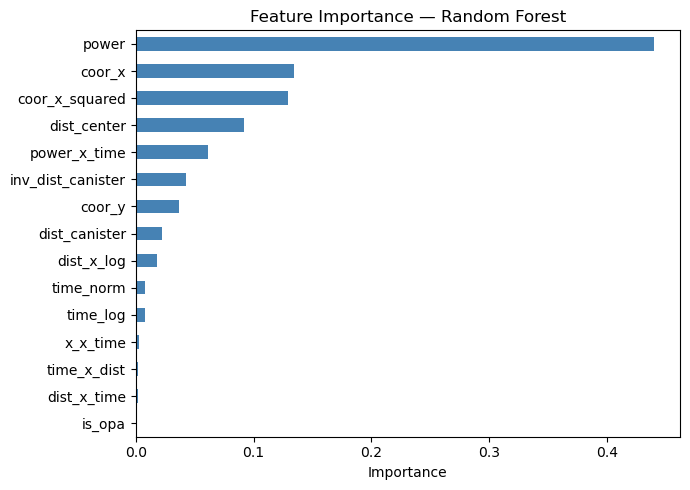

In [13]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Résultats — Random Forest

## 7. Prédictions finales & Soumission

On sélectionne automatiquement le modèle avec le meilleur RMSE de validation.

In [14]:
y_pred = rf.predict(X_test_s)

submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')
print(f'submission.csv sauvegardé — {len(submission)} lignes')
display(submission.head())

Random Forest — RMSE validation : 4.0806
submission.csv sauvegardé — 2190480 lignes


,Id,temperature
0,0,17.176943
1,1,17.176943
2,2,17.176943
3,3,17.176943
4,4,17.176943


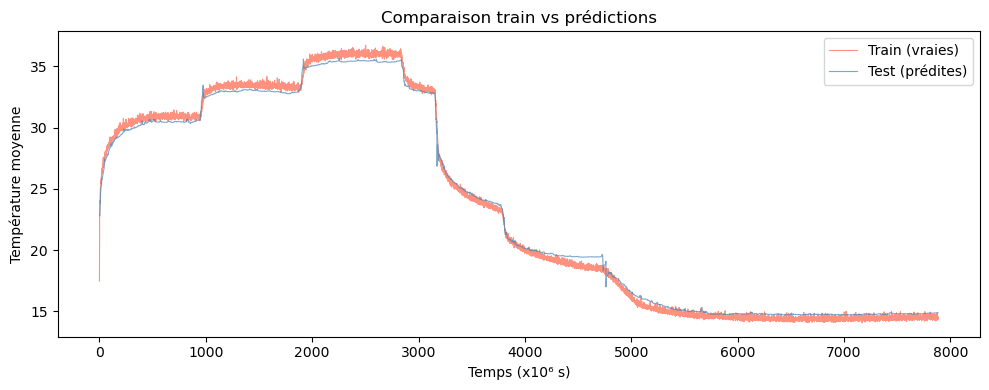

In [15]:
# Comparaison train vs prédictions par timestep
test_with_pred = test.copy()
test_with_pred['temperature_pred'] = y_pred

temp_train = train_clean.groupby('time')['temperature'].mean()
temp_pred  = test_with_pred.groupby('time')['temperature_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_train.index / 1e6, temp_train.values,
         label='Train (vraies)', color='tomato', alpha=0.7, linewidth=0.8)
plt.plot(temp_pred.index / 1e6, temp_pred.values,
         label='Test (prédites)', color='steelblue', alpha=0.7, linewidth=0.8)
plt.title('Comparaison train vs prédictions')
plt.xlabel('Temps (x10⁶ s)')
plt.ylabel('Température moyenne')
plt.legend()
plt.tight_layout()
plt.show()

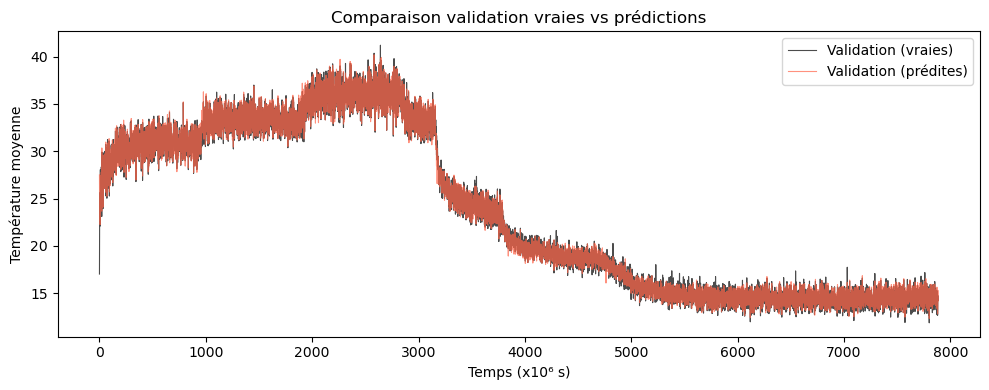

In [23]:
# comparaison validation vs prédictions 
from sklearn.model_selection import train_test_split

idx_all        = np.arange(len(train_feat))
idx_train, idx_val = train_test_split(idx_all, test_size=0.2, random_state=42)

val_with_pred  = train_feat.iloc[idx_val].copy()
val_with_pred['temperature_pred'] = y_pred_val_rf

temp_val_true = val_with_pred.groupby('time')['temperature'].mean()
temp_val_pred = val_with_pred.groupby('time')['temperature_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_val_true.index / 1e6, temp_val_true.values,
         label='Validation (vraies)', color='black', alpha=0.7, linewidth=0.8)
plt.plot(temp_val_pred.index / 1e6, temp_val_pred.values,
         label='Validation (prédites)', color='tomato', alpha=0.7, linewidth=0.8)
plt.title('Comparaison validation vraies vs prédictions')
plt.xlabel('Temps (x10⁶ s)')
plt.ylabel('Température moyenne')
plt.legend()
plt.tight_layout()
plt.show()

## Spatial Temparature Map: True vs Predicted

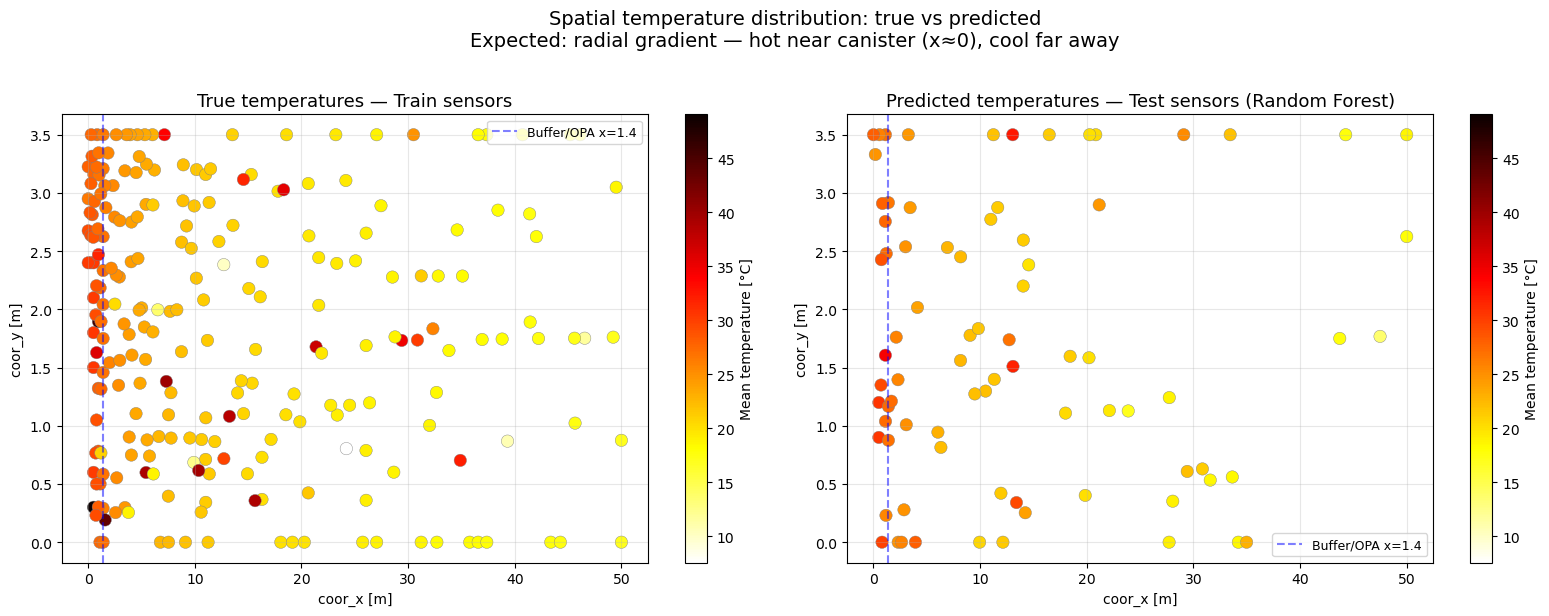

In [16]:
# Spatial temperature map: true vs predicted
# train_clean contient les vraies températures
# test_feat contient les coordonnées du test, y_pred les prédictions

train_sensor_temp = (
    train_clean
    .merge(sensors, on='sensor', how='left')
    .groupby('sensor')
    .agg(coor_x=('coor_x', 'first'), coor_y=('coor_y', 'first'), mean_temp=('temperature', 'mean'))
    .reset_index()
)

test_feat['temp_pred'] = y_pred
test_sensor_temp = (
    test_feat
    .groupby('sensor')
    .agg(coor_x=('coor_x', 'first'), coor_y=('coor_y', 'first'), mean_temp=('temp_pred', 'mean'))
    .reset_index()
)

vmin = min(train_sensor_temp['mean_temp'].min(), test_sensor_temp['mean_temp'].min())
vmax = max(train_sensor_temp['mean_temp'].max(), test_sensor_temp['mean_temp'].max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(
    train_sensor_temp['coor_x'], train_sensor_temp['coor_y'],
    c=train_sensor_temp['mean_temp'], cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[0].axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA x=1.4')
axes[0].set_title('True temperatures — Train sensors', fontsize=13)
axes[0].set_xlabel('coor_x [m]'); axes[0].set_ylabel('coor_y [m]')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Mean temperature [°C]')

sc2 = axes[1].scatter(
    test_sensor_temp['coor_x'], test_sensor_temp['coor_y'],
    c=test_sensor_temp['mean_temp'], cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[1].axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA x=1.4')
axes[1].set_title('Predicted temperatures — Test sensors (Random Forest)', fontsize=13)
axes[1].set_xlabel('coor_x [m]'); axes[1].set_ylabel('coor_y [m]')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='Mean temperature [°C]')

plt.suptitle('Spatial temperature distribution: true vs predicted\n'
             'Expected: radial gradient — hot near canister (x≈0), cool far away',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Error Analysis By sensor

Worst sensors by RMSE:
             mae      rmse     coor_x    coor_y
sensor                                         
N589    4.548791  9.567322   7.327048  1.381086
N550    4.204146  8.504038  13.246674  1.081154
N818    3.398540  7.175244  10.359851  0.616177
N786    3.642772  7.130459   9.903648  0.685591
N165    2.237378  6.418329   7.146852  3.500000
N200    1.282422  5.791157   0.500000  1.500000
N248    1.135239  5.766157  32.323132  1.833475
N622    2.377880  5.738937   3.774802  0.255732
N175    1.239142  5.719717   3.598182  3.500000
N212    1.224692  5.689209   1.400000  2.625000


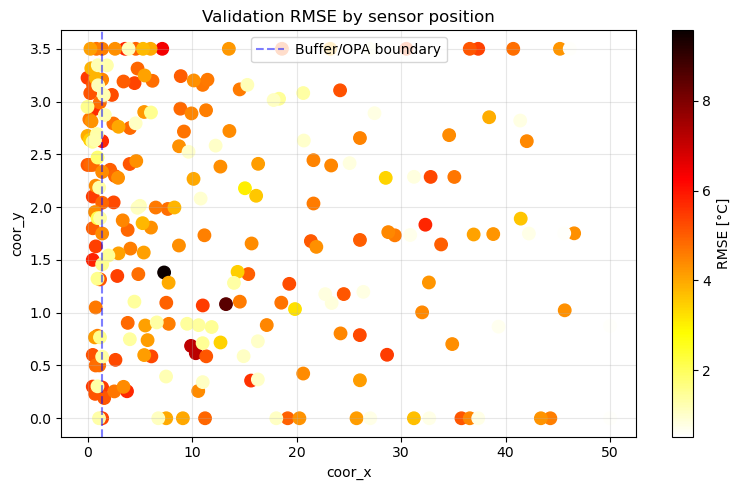

In [17]:
from sklearn.model_selection import train_test_split

# Recréer les mêmes indices que le split original
idx_all   = np.arange(len(train_feat))
idx_train, idx_val = train_test_split(idx_all, test_size=0.2, random_state=42)

val_results = train_feat.iloc[idx_val].copy().reset_index(drop=True)
val_results['y_true']    = y_val
val_results['y_pred']    = y_pred_val_rf
val_results['abs_error'] = np.abs(y_val - y_pred_val_rf)
val_results['sq_error']  = (y_val - y_pred_val_rf)**2

sensor_metrics = (
    val_results
    .groupby('sensor')
    .agg(
        mae   =('abs_error', 'mean'),
        rmse  =('sq_error',  lambda x: np.sqrt(np.mean(x))),
        coor_x=('coor_x', 'first'),
        coor_y=('coor_y', 'first'),
    )
    .sort_values('rmse', ascending=False)
)
print('Worst sensors by RMSE:')
print(sensor_metrics.head(10))

plt.figure(figsize=(8, 5))
sc = plt.scatter(
    sensor_metrics['coor_x'], sensor_metrics['coor_y'],
    c=sensor_metrics['rmse'], cmap='hot_r', s=80
)
plt.colorbar(sc, label='RMSE [°C]')
plt.axvline(1.4, color='blue', linestyle='--', alpha=0.5, label='Buffer/OPA boundary')
plt.xlabel('coor_x'); plt.ylabel('coor_y')
plt.title('Validation RMSE by sensor position')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()